In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [3]:
!pip install kaggle
!kaggle datasets list | head


ref                                                                title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saidaminsaidaxmadov/chocolate-sales                                Chocolate Sales                                      468320  2026-01-04 14:23:35.490000              0        120  1.0              
vishardmehta/indian-engineering-college-placement-dataset          Indian Engineering College Placement Dataset         137603  2026-01-24 15:23:40.150000              0         26  1.0              
rockyt07/social-media-user-analysis                                Social Media User Analysis                        247842357  2026-01-14 02:28:41.970000              0        121  1.0              


In [4]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 70% 153M/218M [00:00<00:00, 1.60GB/s]
100% 218M/218M [00:00<00:00, 911MB/s] 


In [5]:
import zipfile
zip_ref = zipfile.ZipFile("/content/cat-and-dog.zip")
zip_ref.extractall("/content")
zip_ref.close()

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten
from keras.applications.vgg16 import VGG16

In [7]:
conv_base = VGG16(
    weights = 'imagenet', #take imagenet weights as in VGG16
    include_top = False, #remove dense layers only convaolutional layers we want
    input_shape = (150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
conv_base.trainable = True

set_trainable = False
for layers in conv_base.layers:
  if layers.name == 'block5_conv1':
    set_trainable = True
  if set_trainable == True:
    layers.trainable = True
  else:
    layers.trainable = False
  for layer in conv_base.layers:
    print(layer.name,layer.trainable)

input_layer False
block1_conv1 True
block1_conv2 True
block1_pool True
block2_conv1 True
block2_conv2 True
block2_pool True
block3_conv1 True
block3_conv2 True
block3_conv3 True
block3_pool True
block4_conv1 True
block4_conv2 True
block4_conv3 True
block4_pool True
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True
input_layer False
block1_conv1 False
block1_conv2 True
block1_pool True
block2_conv1 True
block2_conv2 True
block2_pool True
block3_conv1 True
block3_conv2 True
block3_conv3 True
block3_pool True
block4_conv1 True
block4_conv2 True
block4_conv3 True
block4_pool True
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True
input_layer False
block1_conv1 False
block1_conv2 False
block1_pool True
block2_conv1 True
block2_conv2 True
block2_pool True
block3_conv1 True
block3_conv2 True
block3_conv3 True
block3_pool True
block4_conv1 True
block4_conv2 True
block4_conv3 True
block4_pool True
block5_conv1 True
block5_conv2 True
block5_conv3 True
blo

In [9]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [10]:
model = Sequential() # Dense layers ko hi train kar rahe hai

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid') )

In [16]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/training_set',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test_set',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(150,150)
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [17]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [18]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
  )

In [19]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 174ms/step - accuracy: 0.7998 - loss: 0.4366 - val_accuracy: 0.8344 - val_loss: 0.3668
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.9284 - loss: 0.1740 - val_accuracy: 0.8917 - val_loss: 0.2516
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.9560 - loss: 0.1216 - val_accuracy: 0.9278 - val_loss: 0.1729
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.9672 - loss: 0.0893 - val_accuracy: 0.9377 - val_loss: 0.1638
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 143ms/step - accuracy: 0.9788 - loss: 0.0607 - val_accuracy: 0.9244 - val_loss: 0.1972
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.9866 - loss: 0.0456 - val_accuracy: 0.9249 - val_loss: 0.1982
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - accuracy: 0.9945 - loss: 0.0283 - val_accuracy: 0.9392 - val_loss: 0.1681
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.9964 - loss: 0

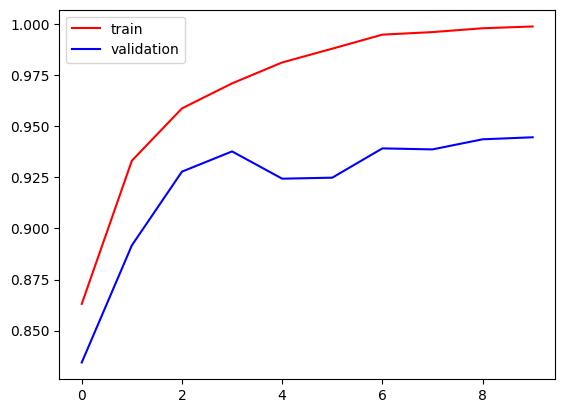

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

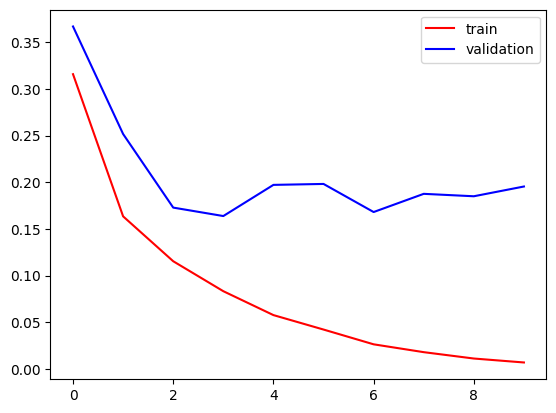

In [21]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

Better